# LWR vs ARZ Attention Bias Visualization

This notebook visualizes the per-segment attention bias computed by `LWRBias` and `ARZBias`.

For a 3-segment piecewise-constant IC, we show:
1. **LWR Bias**: Per-segment bias heatmaps with analytical shock/rarefaction trajectories
2. **ARZ Bias**: Per-segment bias heatmaps with lambda_2-wave and lambda_1-contact trajectories
3. **Comparison**: Side-by-side LWR vs ARZ for equivalent density profiles
4. **Damping effect**: Bias before/after collision time

In [1]:
import sys
sys.path.insert(0, "..")

import torch
import matplotlib.pyplot as plt
import numpy as np

from models.base.lwr_bias import LWRBias
from models.base.arz_bias import ARZBias
from models.base.arz_physics import ARZPhysics
from models.base.flux import GreenshieldsFlux

# --- Shared grid ---
nt, nx = 100, 200
t_lin = torch.linspace(0.01, 0.5, nt)
x_lin = torch.linspace(0.0, 1.0, nx)
t_grid, x_grid = torch.meshgrid(t_lin, x_lin, indexing="ij")  # (nt, nx)
t_coords = t_grid.unsqueeze(0)  # (1, nt, nx)
x_coords = x_grid.unsqueeze(0)  # (1, nt, nx)

# --- 3-segment LWR IC: rho = [0.8, 0.2, 0.6] ---
xs = torch.tensor([[0.0, 0.33, 0.66, 1.0]])      # (1, 4)
ks = torch.tensor([[0.8, 0.2, 0.6]])              # (1, 3)
pieces_mask = torch.tensor([[1.0, 1.0, 1.0]])     # (1, 3)

# --- 3-segment ARZ IC: same rho, velocity v = [0.2, 0.8, 0.4] ---
ks_v = torch.tensor([[0.2, 0.8, 0.4]])            # (1, 3)

## 0. Ground Truth Solutions

Solve the exact same 3-segment ICs with the LWR (Lax-Hopf) and ARZ (Godunov) numerical solvers to see what the model should learn.

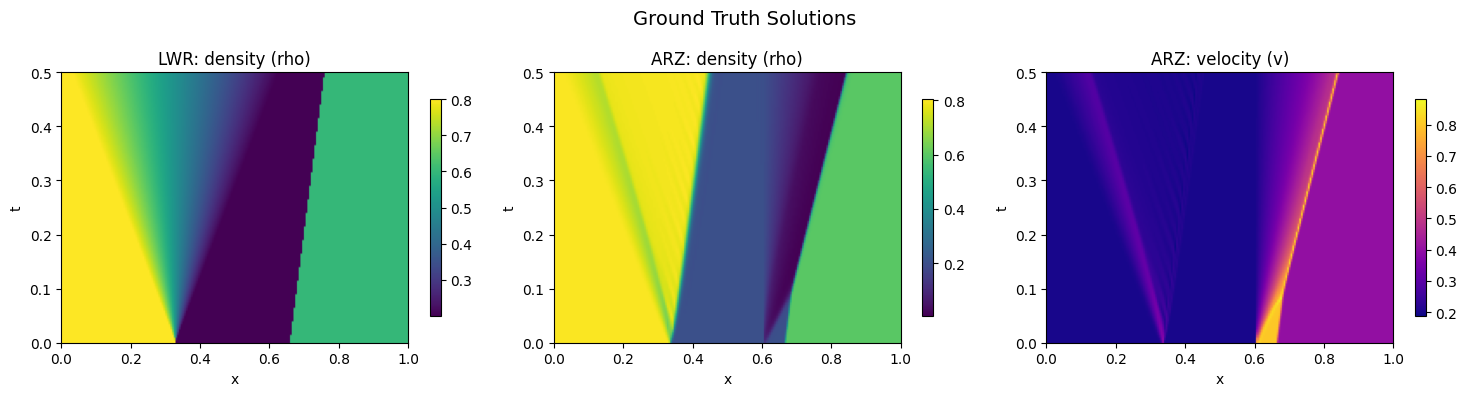

In [7]:
sys.path.insert(0, "../..")  # for numerical_solvers

from numerical_solvers.lwr import generate_one as lwr_solve
from numerical_solvers.arz import generate_one as arz_solve, from_steps as arz_from_steps

# Solver grid parameters (match the query grid)
solver_nx = nx
solver_nt = nt
solver_dx = 1.0 / solver_nx
solver_dt = 0.5 / solver_nt  # T_max = 0.5

# --- LWR ground truth ---
lwr_result = lwr_solve(
    ks=[0.8, 0.2, 0.6],
    xs=[0.0, 0.33, 0.66, 1.0],
    nx=solver_nx, nt=solver_nt, dx=solver_dx, dt=solver_dt,
)
gt_lwr = lwr_result["rho"].float().numpy()  # (nt, nx)

# --- ARZ ground truth ---
x_arz = torch.arange(solver_nx, dtype=torch.float32) * solver_dx
rho0, v0 = arz_from_steps(
    x_arz,
    rho_steps=[(0.33, 0.8), (0.66, 0.2), (1.0, 0.6)],
    v_steps=[(0.6, 0.2), (0.66, 0.8), (1.0, 0.4)],
)
arz_result = arz_solve(
    rho0, v0,
    dx=solver_dx, dt=solver_dt, nt=solver_nt,
    gamma=1.0, bc_type="zero_gradient", flux_type="hll", reconstruction="weno5",
)
gt_arz_rho = arz_result["rho"].float().numpy()  # (nt+1, nx)
gt_arz_v = arz_result["v"].float().numpy()      # (nt+1, nx)

# --- Plot ---
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
extent_gt = [0.0, 1.0, 0.0, 0.5]

im0 = axes[0].imshow(gt_lwr, extent=extent_gt, origin="lower", aspect="auto", cmap="viridis")
axes[0].set_title("LWR: density (rho)")
axes[0].set_xlabel("x"); axes[0].set_ylabel("t")
fig.colorbar(im0, ax=axes[0], shrink=0.8)

im1 = axes[1].imshow(gt_arz_rho[1:], extent=extent_gt, origin="lower", aspect="auto", cmap="viridis")
axes[1].set_title("ARZ: density (rho)")
axes[1].set_xlabel("x"); axes[1].set_ylabel("t")
fig.colorbar(im1, ax=axes[1], shrink=0.8)

im2 = axes[2].imshow(gt_arz_v[1:], extent=extent_gt, origin="lower", aspect="auto", cmap="plasma")
axes[2].set_title("ARZ: velocity (v)")
axes[2].set_xlabel("x"); axes[2].set_ylabel("t")
fig.colorbar(im2, ax=axes[2], shrink=0.8)

fig.suptitle("Ground Truth Solutions", fontsize=14)
plt.tight_layout()
plt.show()

## 1. LWR Bias: Per-Segment Heatmaps

/var/folders/l2/j581hbb53nb9hn1507fwv24w0000gn/T/ipykernel_27565/3245834595.py:40: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


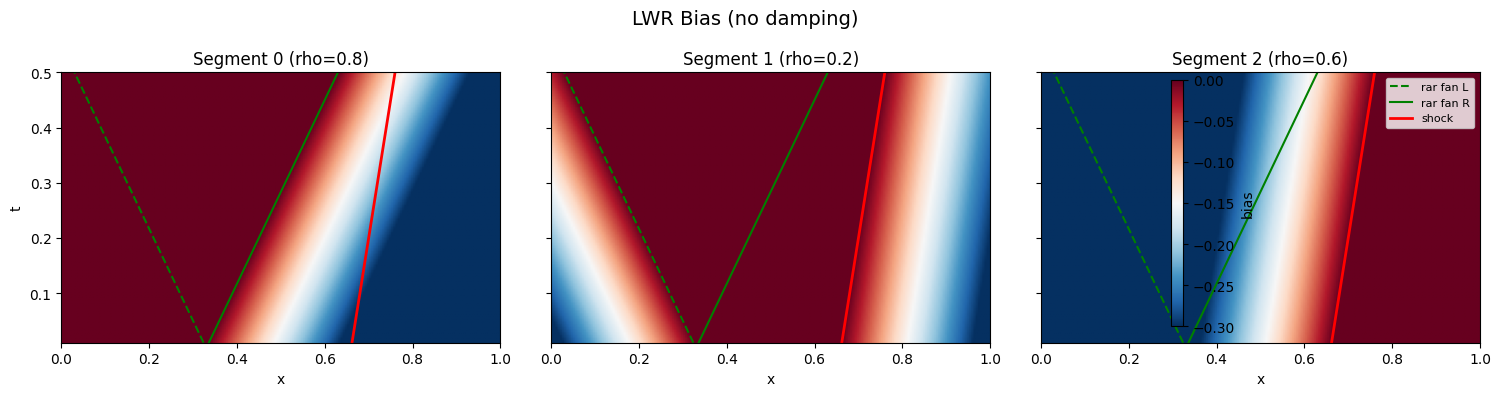

In [3]:
flux = GreenshieldsFlux()
lwr_bias_module = LWRBias(flux=flux, use_damping=False)

with torch.no_grad():
    ic_data_lwr = {"xs": xs, "ks": ks, "pieces_mask": pieces_mask}
    bias_lwr = lwr_bias_module(ic_data_lwr, (t_coords, x_coords))  # (1, nt, nx, 3)
    bias_lwr = bias_lwr[0].numpy()  # (nt, nx, 3)

# Analytical trajectories
lam = (1 - 2 * ks[0]).numpy()  # Greenshields: f'(rho) = 1 - 2*rho
xs_np = xs[0].numpy()
ks_np = ks[0].numpy()

# Interface 0 (x=0.33): rho_L=0.8, rho_R=0.2 -> lam_L=-0.6 < lam_R=0.6 -> rarefaction
# Interface 1 (x=0.66): rho_L=0.2, rho_R=0.6 -> lam_L=0.6 > lam_R=-0.2 -> shock
s_shock = 1 - ks_np[1] - ks_np[2]  # Greenshields shock speed

t_plot = t_lin.numpy()
extent = [x_lin[0], x_lin[-1], t_lin[0], t_lin[-1]]

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for k in range(3):
    im = axes[k].imshow(
        bias_lwr[:, :, k], extent=extent, origin="lower", aspect="auto",
        cmap="RdBu_r", vmin=-0.3, vmax=0.0,
    )
    axes[k].set_title(f"Segment {k} (rho={ks_np[k]:.1f})")
    axes[k].set_xlabel("x")
    # Overlay trajectories
    # Rarefaction fan at interface 0
    axes[k].plot(xs_np[1] + lam[0] * t_plot, t_plot, "g--", lw=1.5, label="rar fan L")
    axes[k].plot(xs_np[1] + lam[1] * t_plot, t_plot, "g-", lw=1.5, label="rar fan R")
    # Shock at interface 1
    axes[k].plot(xs_np[2] + s_shock * t_plot, t_plot, "r-", lw=2, label="shock")

axes[0].set_ylabel("t")
axes[2].legend(loc="upper right", fontsize=8)
fig.colorbar(im, ax=axes, shrink=0.8, label="bias")
fig.suptitle("LWR Bias (no damping)", fontsize=14)
plt.tight_layout()
plt.show()

## 2. ARZ Bias: Per-Segment Heatmaps

lam2 = [-0.6         0.6        -0.20000002]
lam1 (contact) = [0.2 0.8 0.4]


/var/folders/l2/j581hbb53nb9hn1507fwv24w0000gn/T/ipykernel_27565/73974500.py:52: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


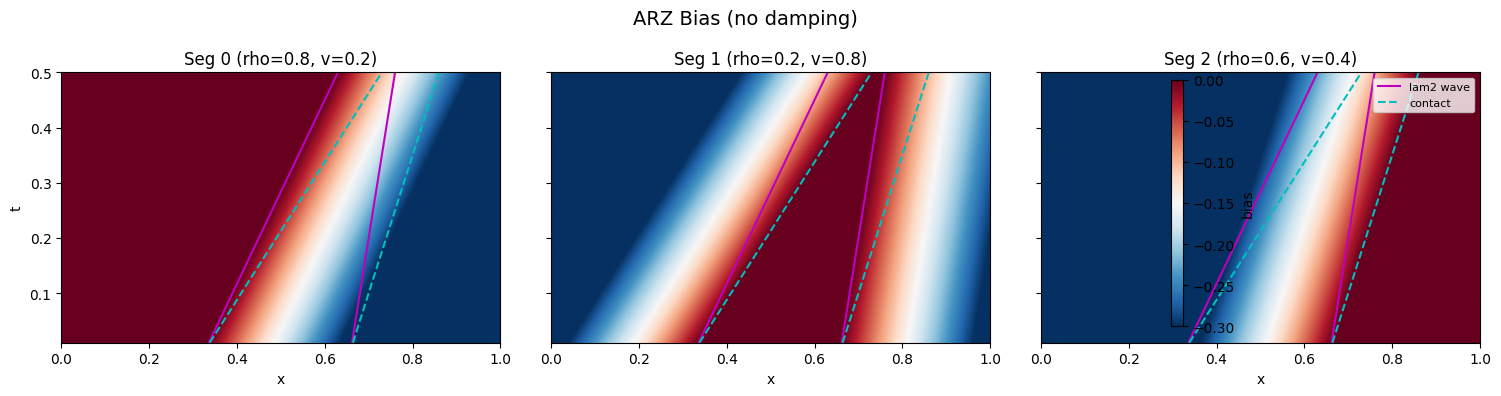

In [8]:
gamma = 1.0
physics = ARZPhysics(gamma=gamma)
arz_bias_module = ARZBias(arz_physics=physics, use_damping=False)

with torch.no_grad():
    ic_data_arz = {"xs": xs, "ks": ks, "ks_v": ks_v, "pieces_mask": pieces_mask}
    bias_arz = arz_bias_module(ic_data_arz, (t_coords, x_coords))  # (1, nt, nx, 3)
    bias_arz = bias_arz[0].numpy()  # (nt, nx, 3)

# Eigenvalues
rho = ks[0].numpy()
v = ks_v[0].numpy()
lam1 = v  # contact speed
lam2 = v - rho * gamma * rho ** (gamma - 1)  # GNL eigenvalue

# Interface 0 (x=0.33): lam2_L vs lam2_R
# Interface 1 (x=0.66): lam2_L vs lam2_R
print(f"lam2 = {lam2}")
print(f"lam1 (contact) = {lam1}")

# RH shock speed at each interface
s0 = (rho[1] * v[1] - rho[0] * v[0]) / (rho[1] - rho[0] + 1e-8)
s1 = (rho[2] * v[2] - rho[1] * v[1]) / (rho[2] - rho[1] + 1e-8)
is_shock_0 = lam2[0] > lam2[1]
is_shock_1 = lam2[1] > lam2[2]

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for k in range(3):
    im = axes[k].imshow(
        bias_arz[:, :, k], extent=extent, origin="lower", aspect="auto",
        cmap="RdBu_r", vmin=-0.3, vmax=0.0,
    )
    axes[k].set_title(f"Seg {k} (rho={rho[k]:.1f}, v={v[k]:.1f})")
    axes[k].set_xlabel("x")

    # Interface 0 trajectories
    speed_lam2_0 = s0 if is_shock_0 else lam2[1]  # left seg boundary
    speed_contact_0 = v[1]  # right seg boundary
    axes[k].plot(xs_np[1] + speed_lam2_0 * t_plot, t_plot, "m-", lw=1.5, label="lam2 wave")
    axes[k].plot(xs_np[1] + speed_contact_0 * t_plot, t_plot, "c--", lw=1.5, label="contact")

    # Interface 1 trajectories
    speed_lam2_1 = s1 if is_shock_1 else lam2[2]
    speed_contact_1 = v[2]
    axes[k].plot(xs_np[2] + speed_lam2_1 * t_plot, t_plot, "m-", lw=1.5)
    axes[k].plot(xs_np[2] + speed_contact_1 * t_plot, t_plot, "c--", lw=1.5)

axes[0].set_ylabel("t")
axes[2].legend(loc="upper right", fontsize=8)
fig.colorbar(im, ax=axes, shrink=0.8, label="bias")
fig.suptitle("ARZ Bias (no damping)", fontsize=14)
plt.tight_layout()
plt.show()

## 3. Side-by-Side Comparison: LWR vs ARZ

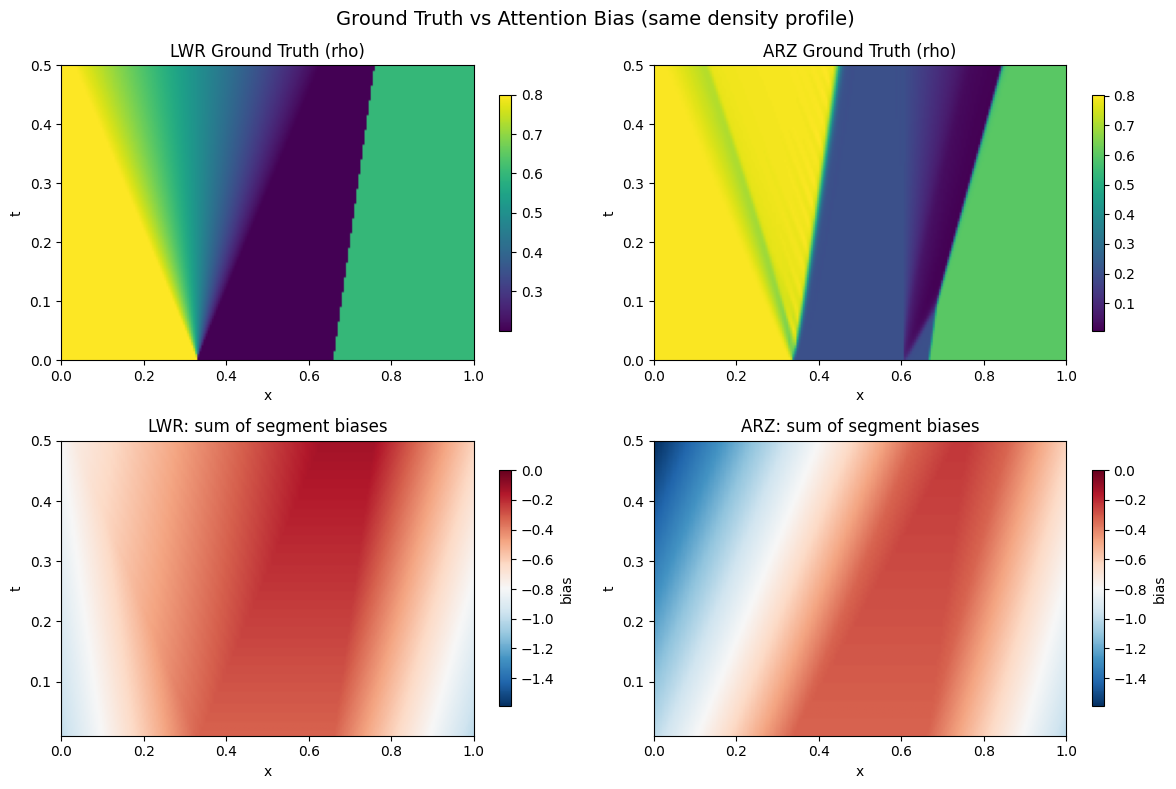

In [9]:
# Sum across segments to get total bias at each (t, x)
total_lwr = bias_lwr.sum(axis=-1)  # (nt, nx)
total_arz = bias_arz.sum(axis=-1)  # (nt, nx)

vmin = min(total_lwr.min(), total_arz.min())
vmax = 0.0

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Top row: ground truth
im_gt0 = axes[0, 0].imshow(gt_lwr, extent=extent_gt, origin="lower", aspect="auto", cmap="viridis")
axes[0, 0].set_title("LWR Ground Truth (rho)")
axes[0, 0].set_xlabel("x"); axes[0, 0].set_ylabel("t")
fig.colorbar(im_gt0, ax=axes[0, 0], shrink=0.8)

im_gt1 = axes[0, 1].imshow(gt_arz_rho[1:], extent=extent_gt, origin="lower", aspect="auto", cmap="viridis")
axes[0, 1].set_title("ARZ Ground Truth (rho)")
axes[0, 1].set_xlabel("x"); axes[0, 1].set_ylabel("t")
fig.colorbar(im_gt1, ax=axes[0, 1], shrink=0.8)

# Bottom row: total bias
im0 = axes[1, 0].imshow(
    total_lwr, extent=extent, origin="lower", aspect="auto",
    cmap="RdBu_r", vmin=vmin, vmax=vmax,
)
axes[1, 0].set_title("LWR: sum of segment biases")
axes[1, 0].set_xlabel("x"); axes[1, 0].set_ylabel("t")
fig.colorbar(im0, ax=axes[1, 0], shrink=0.8, label="bias")

im1 = axes[1, 1].imshow(
    total_arz, extent=extent, origin="lower", aspect="auto",
    cmap="RdBu_r", vmin=vmin, vmax=vmax,
)
axes[1, 1].set_title("ARZ: sum of segment biases")
axes[1, 1].set_xlabel("x"); axes[1, 1].set_ylabel("t")
fig.colorbar(im1, ax=axes[1, 1], shrink=0.8, label="bias")

fig.suptitle("Ground Truth vs Attention Bias (same density profile)", fontsize=14)
plt.tight_layout()
plt.show()

## 4. Damping Effect: Before vs After Collision Time

/var/folders/l2/j581hbb53nb9hn1507fwv24w0000gn/T/ipykernel_27565/4052582941.py:34: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


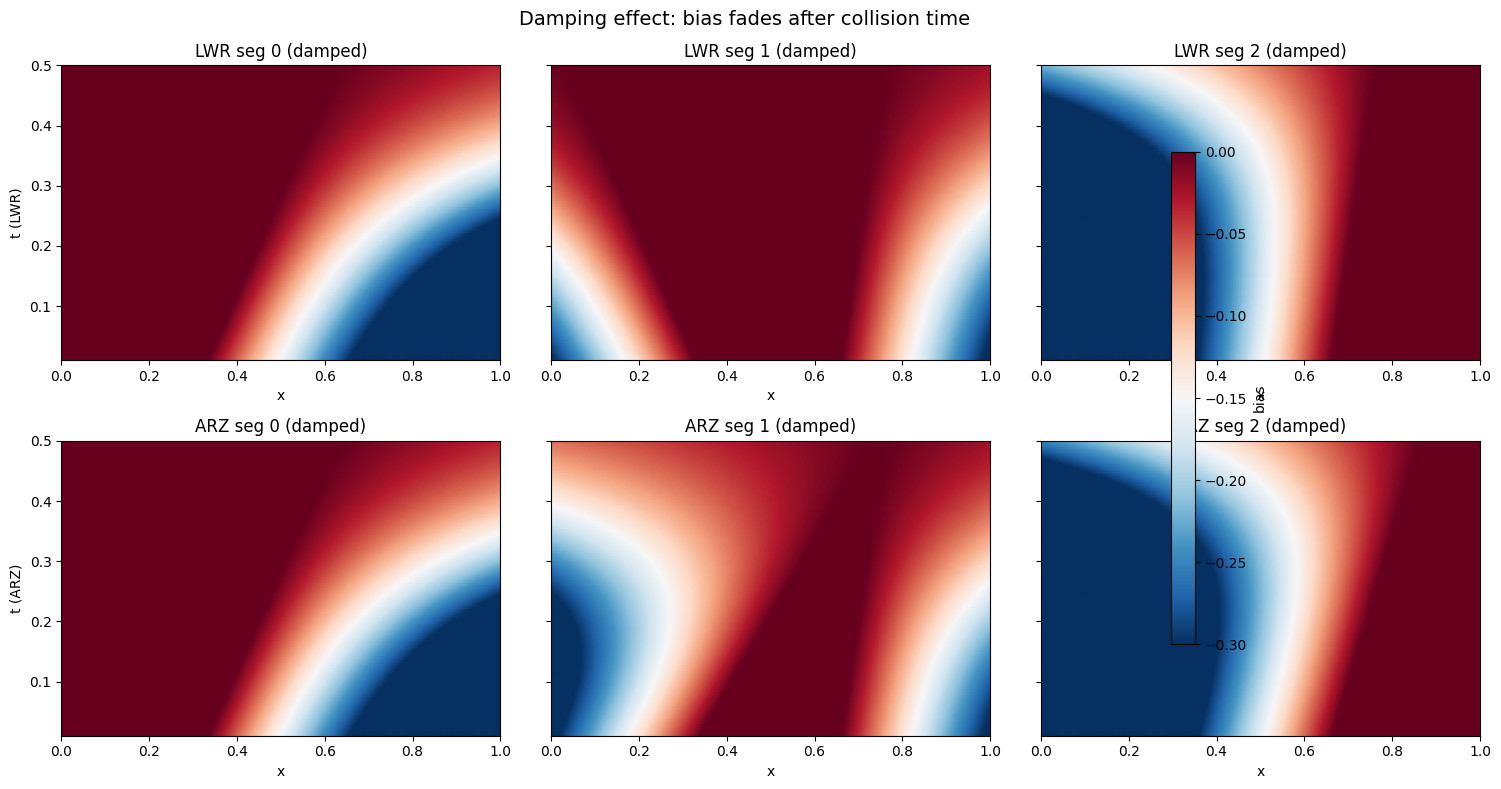

In [6]:
# LWR with damping
lwr_damped = LWRBias(flux=flux, use_damping=True, initial_damping_sharpness=10.0)
with torch.no_grad():
    bias_lwr_damped = lwr_damped(ic_data_lwr, (t_coords, x_coords))[0].numpy()

# ARZ with damping
arz_damped = ARZBias(arz_physics=physics, use_damping=True, initial_damping_sharpness=10.0)
with torch.no_grad():
    bias_arz_damped = arz_damped(ic_data_arz, (t_coords, x_coords))[0].numpy()

fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharey=True)

for k in range(3):
    # LWR damped
    axes[0, k].imshow(
        bias_lwr_damped[:, :, k], extent=extent, origin="lower", aspect="auto",
        cmap="RdBu_r", vmin=-0.3, vmax=0.0,
    )
    axes[0, k].set_title(f"LWR seg {k} (damped)")
    axes[0, k].set_xlabel("x")

    # ARZ damped
    im = axes[1, k].imshow(
        bias_arz_damped[:, :, k], extent=extent, origin="lower", aspect="auto",
        cmap="RdBu_r", vmin=-0.3, vmax=0.0,
    )
    axes[1, k].set_title(f"ARZ seg {k} (damped)")
    axes[1, k].set_xlabel("x")

axes[0, 0].set_ylabel("t (LWR)")
axes[1, 0].set_ylabel("t (ARZ)")
fig.colorbar(im, ax=axes, shrink=0.8, label="bias")
fig.suptitle("Damping effect: bias fades after collision time", fontsize=14)
plt.tight_layout()
plt.show()